# 基礎分析：トップリバー
- データ前処理の前処理は1回だけ行えば良い（処理済みデータを書き出せばOK）
- 以降、データ前処理で処理済みデータを読み込んで前処理を行い、各分析に進む

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy.optimize import curve_fit

sns.set_style('whitegrid')
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Yu Gothic', 'Meirio']

## データ前処理の前処理

In [2]:
#--変数設定
farm_excel = 'farm/【Confidential】サンプルデータ（トップリバー様） (2).xlsx'
excel_sheet = 'トップリバー様（NDVI）'
lettuce_file = "farm/topriver_lettuce_list.csv"
output_file = "farm/topriver_data.csv"

In [3]:
#--Excelデータファイル読み込み
df_org = pd.read_excel(farm_excel, sheet_name=excel_sheet)
print("データ量：元データ", df_org.shape)

#--データ処理(ポリゴン列の削除、年度・経過日の型)
df_org = df_org.drop(columns=['polygon']).dropna().reset_index(drop=True)
df_org['年度'] = df_org['年度'].astype(int)
df_org['経過日'] = df_org['経過日'].astype(int)
print("データ量：データ処理後", df_org.shape)

データ量：元データ (26832, 8)
データ量：データ処理後 (26777, 7)


In [4]:
#--レタス品種リストを読み込み
lettuce = pd.read_csv("farm/topriver_lettuce_list.csv")['栽培グループ名'].to_list()

#--データをレタスの品種に絞る
df_farm = df_org.query("栽培グループ名 in @lettuce").reset_index(drop=True)
print("データ量：レタスのみ", df_farm.shape)

#--残ったデータのレタスの品種確認
print("品種：", len(df_farm['栽培グループ名'].unique()))
df_farm['栽培グループ名'].unique()

データ量：レタスのみ (25191, 7)
品種： 26


array(['【新】御代田地区：ウィザード', '【新】御代田地区：スターレイ', '富士見地区：TLE-567', '富士見地区：ウィザード',
       '富士見地区：エスコート', '富士見地区：オーウェン', '富士見地区：グリーンブーケ', '富士見地区：サマーガイ',
       '富士見地区：スターレイ', '富士見地区：ツインデル', '富士見地区：ハイジ', '富士見地区：ファンファーレ',
       '富士見地区：フリフリッカー', '富士見地区：フレデリック', '富士見地区：ペネトレイト', '富士見地区：ルシナ66',
       '御代田地区：ウィザード', '御代田地区：エスコート', '御代田地区：スターレイ', '御代田地区：ハイジ',
       '御代田地区：ファンファーレ', '御代田地区：フレデリック', '御代田地区：ペネトレイト', '御代田地区：ルシナ66',
       '東御地区：ウィザード', '東御地区：スターレイ'], dtype=object)

- 『エリア名：レタス品種名』48種のうち、データ欠損行を削除すると、有効な『エリア名：レタス品種名』は26種となった

In [5]:
#--処理済みデータ書き出し
df_farm.to_csv(output_file, index=False)

### 2025年追加データの前処理

In [6]:
#--追加のデータ（通常のxlsxフォーマット変換後）
farm_excel = 'farm/【Confidential】サンプルデータ_トップリバー様_251203.xlsx'
excel_sheet = 'トップリバー様'
lettuce_file = "farm/topriver_lettuce_list.csv"
output_file = "farm/topriver_data_2025.csv"

In [7]:
#--Excelデータファイル読み込み
df_org = pd.read_excel(farm_excel, sheet_name=excel_sheet)
print("データ量：元データ", df_org.shape)

#--データ処理(2025年分のみ、ポリゴン列の削除、年度・経過日の型)
df_org = df_org.query("年度 == 2025").reset_index(drop=True)
df_org = df_org.drop(columns=['polygon']).dropna().reset_index(drop=True)
df_org['年度'] = df_org['年度'].astype(int)
df_org['経過日'] = df_org['経過日'].astype(int)
print("データ量：データ処理後", df_org.shape)

データ量：元データ (26457, 8)
データ量：データ処理後 (3488, 7)


In [8]:
#--レタス品種リストを読み込み
lettuce = pd.read_csv("farm/topriver_lettuce_list.csv")['栽培グループ名'].to_list()

#--データをレタスの品種に絞る
df_farm = df_org.query("栽培グループ名 in @lettuce").reset_index(drop=True)
print("データ量：レタスのみ", df_farm.shape)

#--残ったデータのレタスの品種確認
print("品種：", len(df_farm['栽培グループ名'].unique()))
df_farm['栽培グループ名'].unique()

データ量：レタスのみ (3488, 7)
品種： 14


array(['富士見地区：ウィザード', '富士見地区：エスコート', '富士見地区：ファンファーレ', '富士見地区：ペネトレイト',
       '富士見地区：ルシナ66', '御代田地区：エスコート', '御代田地区：スターレイ', '御代田地区：ヒートガイ',
       '御代田地区：ファンファーレ', '御代田地区：フレデリック', '御代田地区：ペネトレイト', '御代田地区：ルシナ66',
       '東御地区：ウィザード', '東御地区：スターレイ'], dtype=object)

In [9]:
#--処理済みデータ書き出し
df_farm.to_csv(output_file, index=False)

## データ前処理

In [2]:
#--変数設定
input_file = "farm/topriver_data.csv"
remove_list = "farm/topriver_remove_list.csv"

#--処理済みデータ読み込み
df_farm = pd.read_csv(input_file, parse_dates=['定植日','収穫日'])
#--除外リスト読み込み
df_remove = pd.read_csv(remove_list)

In [3]:
#--解析対象から除外するデータを削除
for index, row in df_remove.iterrows():
    group = row['栽培グループ名']
    field = row['圃場名']
    year = row['年度']
    df_farm = df_farm.query("not (栽培グループ名 == @group and 圃場名 == @field and 年度 == @year)").reset_index(drop=True)

In [4]:
#--栽培グループ名を地区と品種に分割
df_farm[['地区','品種']] = df_farm['栽培グループ名'].str.split("：",expand=True)
#--栽培日数(収穫日-定植日)を計算
df_farm['栽培日数'] = (df_farm['収穫日']-df_farm['定植日']).dt.days
#--定植日＋経過日で各データの対象日を計算
df_farm['日付'] = df_farm['定植日'] + pd.to_timedelta(df_farm['経過日'], unit='D')
#--人がわかりやすいように並べ替え
df_farm = df_farm[['栽培グループ名', '地区', '品種', '圃場名', '年度', '定植日', '収穫日', '栽培日数', '経過日', '日付', 'NDVI値']]
# df_farm.iloc[15:20]

- 圃場ごとに、収穫日と最後のデータの日付（栽培日数と経過日）は、必ずしもあっていない

In [5]:
#--栽培日数よりも長い経過日は削除しておく
df_farm = df_farm.query("栽培日数 >= 経過日").reset_index(drop=True)

#--NDVI値がゼロは、欠損に変えておく
df_farm['NDVI値'] = df_farm['NDVI値'].mask(df_farm['NDVI値']==0, np.nan)

---

## データ分析

### NDVIの時系列グラフ試作

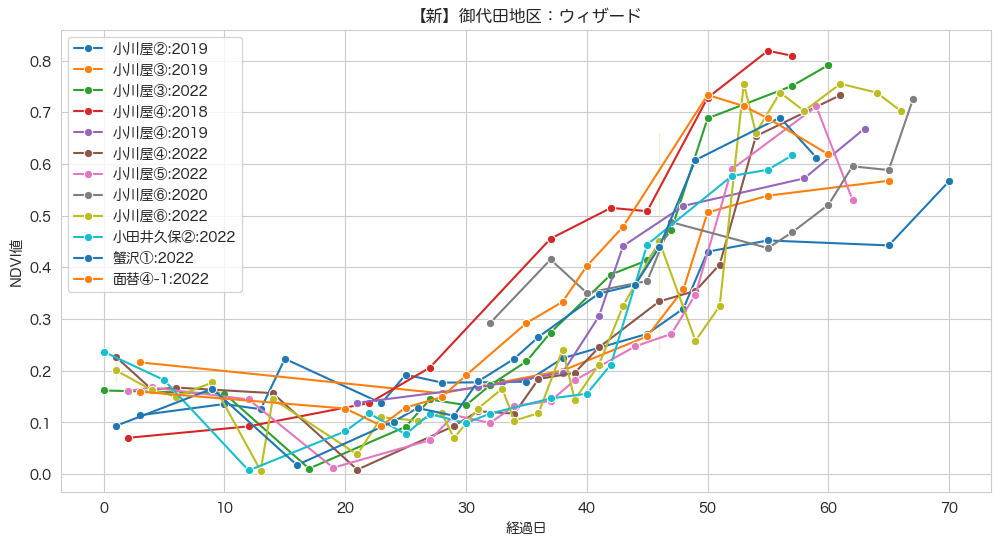

In [5]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    plt.legend()
    plt.title(group)
    plt.show()
    break

- 全体的にはこっちの描画方法が見やすいが、小川屋⑥の変な値がうまく描画されていないように見える（下図参照）

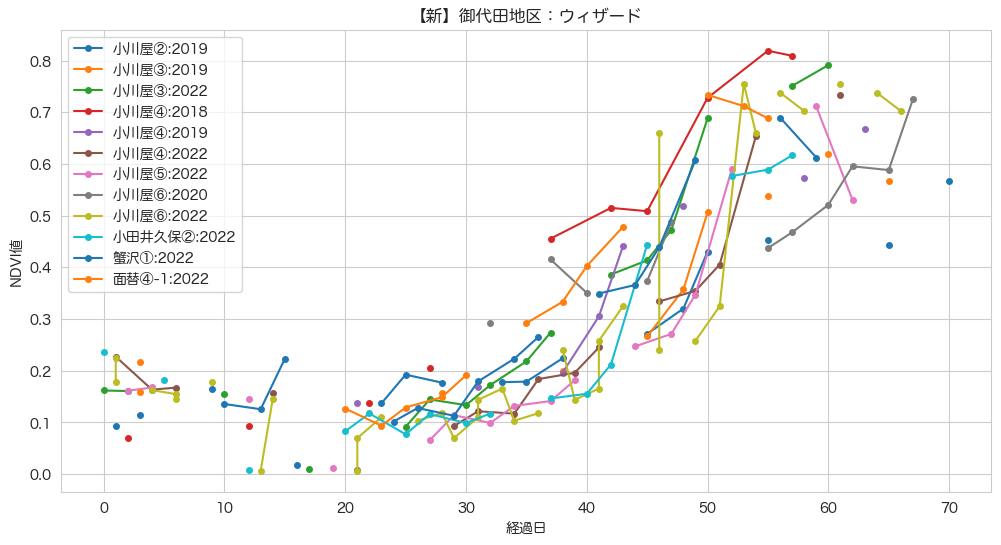

In [7]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        ax.plot(df['経過日'], df['NDVI値'], '-o', ms=4, label=f'{field}:{year}')
    plt.xlabel("経過日")
    plt.ylabel("NDVI値")
    plt.legend()
    plt.title(group)
    plt.show()
    break

- 小川屋⑥:2022に変なデータがありそうなので、別途さぐる
- ↑調べたところ、連続する経過日でありながら値が大きく違ったり、同じ日なのに値が複数ある場合があることがわかった

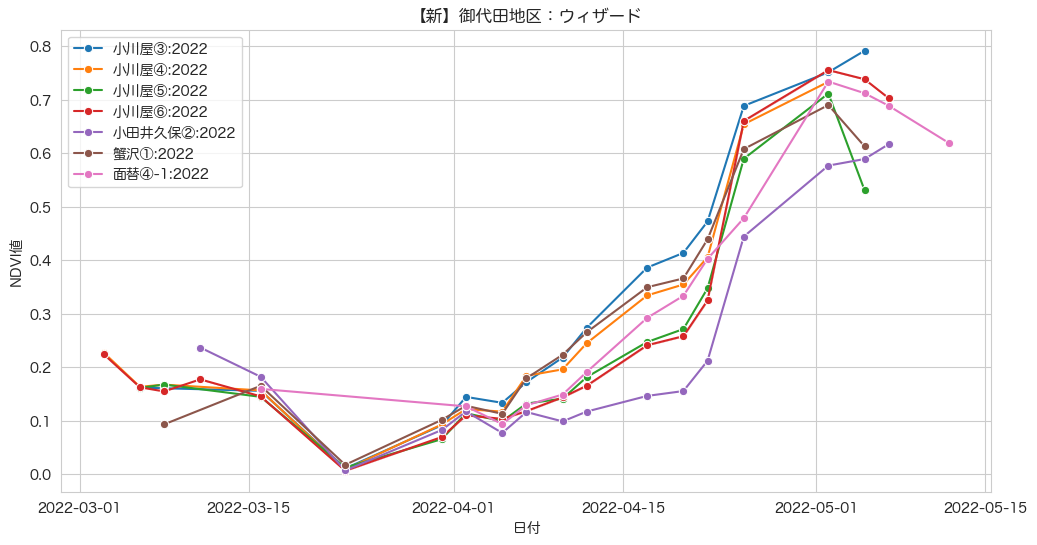

In [8]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        if year != 2022: continue
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for (field, year), df in df_year.groupby(['圃場名','年度']):
            sns.lineplot(data=df, x='日付', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
        plt.legend()
        plt.title(group)
        plt.show()
        break
    break

- 横軸を経過日ではなく対象日の日付にすると、3月下旬のNDVIの落ち込みが何らか解析の影響（雲など）による可能性が見えてくる

### 全部描画（線で繋ぐ版）

In [ ]:
#--画像出力先フォルダ作成
fig_dir = "fig/topriver/line"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    ax.set_xlabel("経過日")
    ax.set_ylabel("NDVI値")
    ax.set_title(group)
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    # plt.tight_layout()  # 枠外の凡例が切れないよう調整
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 全部描画（とびとびあり版）

In [9]:
#--画像出力先フォルダ作成
fig_dir = "fig/topriver/discrete"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    # print(group)
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        # print(field,year)
        ax.plot(df['経過日'], df['NDVI値'], '-o', ms=4, label=f'{field}:{year}')
        # sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
    ax.set_xlabel("経過日")
    ax.set_ylabel("NDVI値")
    ax.set_title(group)
    ax.legend(
        bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
        loc='upper left',          # 凡例ボックスの基準位置
        borderaxespad=0.,          # グラフとの隙間
        fontsize=9,                # 凡例の文字サイズ（調整可）
    )
    # plt.tight_layout()  # 枠外の凡例が切れないよう調整
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

### 全部描画（線で繋ぐ版・年ごと）
- 圃場ごとの描画だと数が多いため、圃場ごと・年度ごとに分けて描画する

In [7]:
#--画像出力先フォルダ作成
fig_dir = "fig/topriver/yearly"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for field, df in df_year.groupby('圃場名'):
            sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=field, ax=ax)
        ax.set_xlabel("経過日")
        ax.set_ylabel("NDVI値")
        ax.set_title(f"{group} : {year}年度")
        ax.legend(
            bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
            loc='upper left',          # 凡例ボックスの基準位置
            borderaxespad=0.,          # グラフとの隙間
            fontsize=9,                # 凡例の文字サイズ（調整可）
        )
        # plt.tight_layout()  # 枠外の凡例が切れないよう調整
        plt.savefig(f"{fig_dir}/{group}_{year}.png", bbox_inches='tight')
        plt.close()
        # plt.show()

### 全部描画（線で繋ぐ版・年ごと）
- 横軸を経過日ではなく対象日の日付にした図も作成しておく

In [8]:
#--画像出力先フォルダ作成
fig_dir = "fig/topriver/dateaxis"
os.makedirs(fig_dir, exist_ok=True)

#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        fig = plt.figure(figsize=(12,6))
        ax = fig.add_subplot(1,1,1)
        for field, df in df_year.groupby('圃場名'):
            sns.lineplot(data=df, x='日付', y='NDVI値', marker='o', label=field, ax=ax)
        ax.set_xlabel("経過日")
        ax.set_ylabel("NDVI値")
        ax.set_title(f"{group} : {year}年度")
        ax.legend(
            bbox_to_anchor=(1.05, 1),  # 凡例をグラフ右外に配置
            loc='upper left',          # 凡例ボックスの基準位置
            borderaxespad=0.,          # グラフとの隙間
            fontsize=9,                # 凡例の文字サイズ（調整可）
        )
        # plt.tight_layout()  # 枠外の凡例が切れないよう調整
        plt.savefig(f"{fig_dir}/{group}_{year}.png", bbox_inches='tight')
        plt.close()
        # plt.show()

### 同一グループ・同年度の圃場における定植日・収穫日の重複の確認
- 小川屋⑥の2022年度には複数の定植日・収穫日があった
- 同様のケースがないか調べる

In [ ]:
#--定植日に重複がある圃場・年度を書き出す
for group, df_group in df_farm.groupby('栽培グループ名'):
    for year, df_year in df_group.groupby('年度'):
        for field, df in df_year.groupby('圃場名'):
            if len(df['定植日'].unique()) > 1:
                print(group, field, year)

【新】御代田地区：ウィザード 小川屋⑥ 2022
富士見地区：ペネトレイト 立沢線東② 2024
富士見地区：ルシナ66 四段正面③ 2024
御代田地区：スターレイ 東御⑤ 2024
御代田地区：ペネトレイト 上西田下 2024


### 各種統計量の分析

In [6]:
#--栽培グループごとに栽培日数の統計量を計算
df_days = df_farm.drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)
df_days.groupby('栽培グループ名').aggregate({'栽培日数':['mean','std','min','max','count']}).round(1)

栽培日数                   
                mean  std min max count
栽培グループ名                                
【新】御代田地区：ウィザード  63.5  4.1  58  71    11
【新】御代田地区：スターレイ  60.5  3.5  53  70    54
富士見地区：TLE-567   47.7  3.8  42  56     9
富士見地区：ウィザード     50.6  2.3  47  56    41
富士見地区：エスコート     46.6  4.1  38  52    16
富士見地区：オーウェン     45.2  3.2  36  52    55
富士見地区：グリーンブーケ   49.0  NaN  49  49     1
富士見地区：サマーガイ     37.3  2.4  34  42    14
富士見地区：スターレイ     48.8  3.0  42  56    38
富士見地区：ツインデル     47.9  3.4  43  53    13
富士見地区：ハイジ       40.8  3.4  35  50    92
富士見地区：ファンファーレ   41.5  3.0  35  49    78
富士見地区：フリフリッカー   46.1  4.8  36  57    53
富士見地区：フレデリック    57.0  NaN  57  57     1
富士見地区：ペネトレイト    49.1  3.3  42  66    67
富士見地区：ルシナ66     45.9  4.3  36  57    43
御代田地区：ウィザード     64.4  3.7  60  71    11
御代田地区：エスコート     52.9  4.7  41  74    64
御代田地区：スターレイ     60.6  3.4  53  70    57
御代田地区：ハイジ       39.9  2.9  34  47    16
御代田地区：ファンファーレ   42.5  3.5  37  54    76
御代田地区：フレデリック    51.0  8.5  45  57     2
御代田地区：ペネトレイト    55.0  2.9  50  65   137
御代田地区：ルシナ66     48.7  6.5  30  67   110
東御地区：ウィザード      65.8  3.6  60  74    53
東御地区：スターレイ      63.1  4.2  57  71    30

- 同じ品種でも栽培地域によって栽培日数が異なる
    - 御代田地区は標高1000m未満、富士見地区は標高1000m以上と思われるが、富士見地区の方が栽培日数が小さい
    - 標高データはメッシュ農業気象データ1kmメッシュから取っている（1km四方の平均）
- ここで御代田地区と東御地区の両方に東御という名の圃場があることに気づく。両者のポリゴンやNDVIは一致

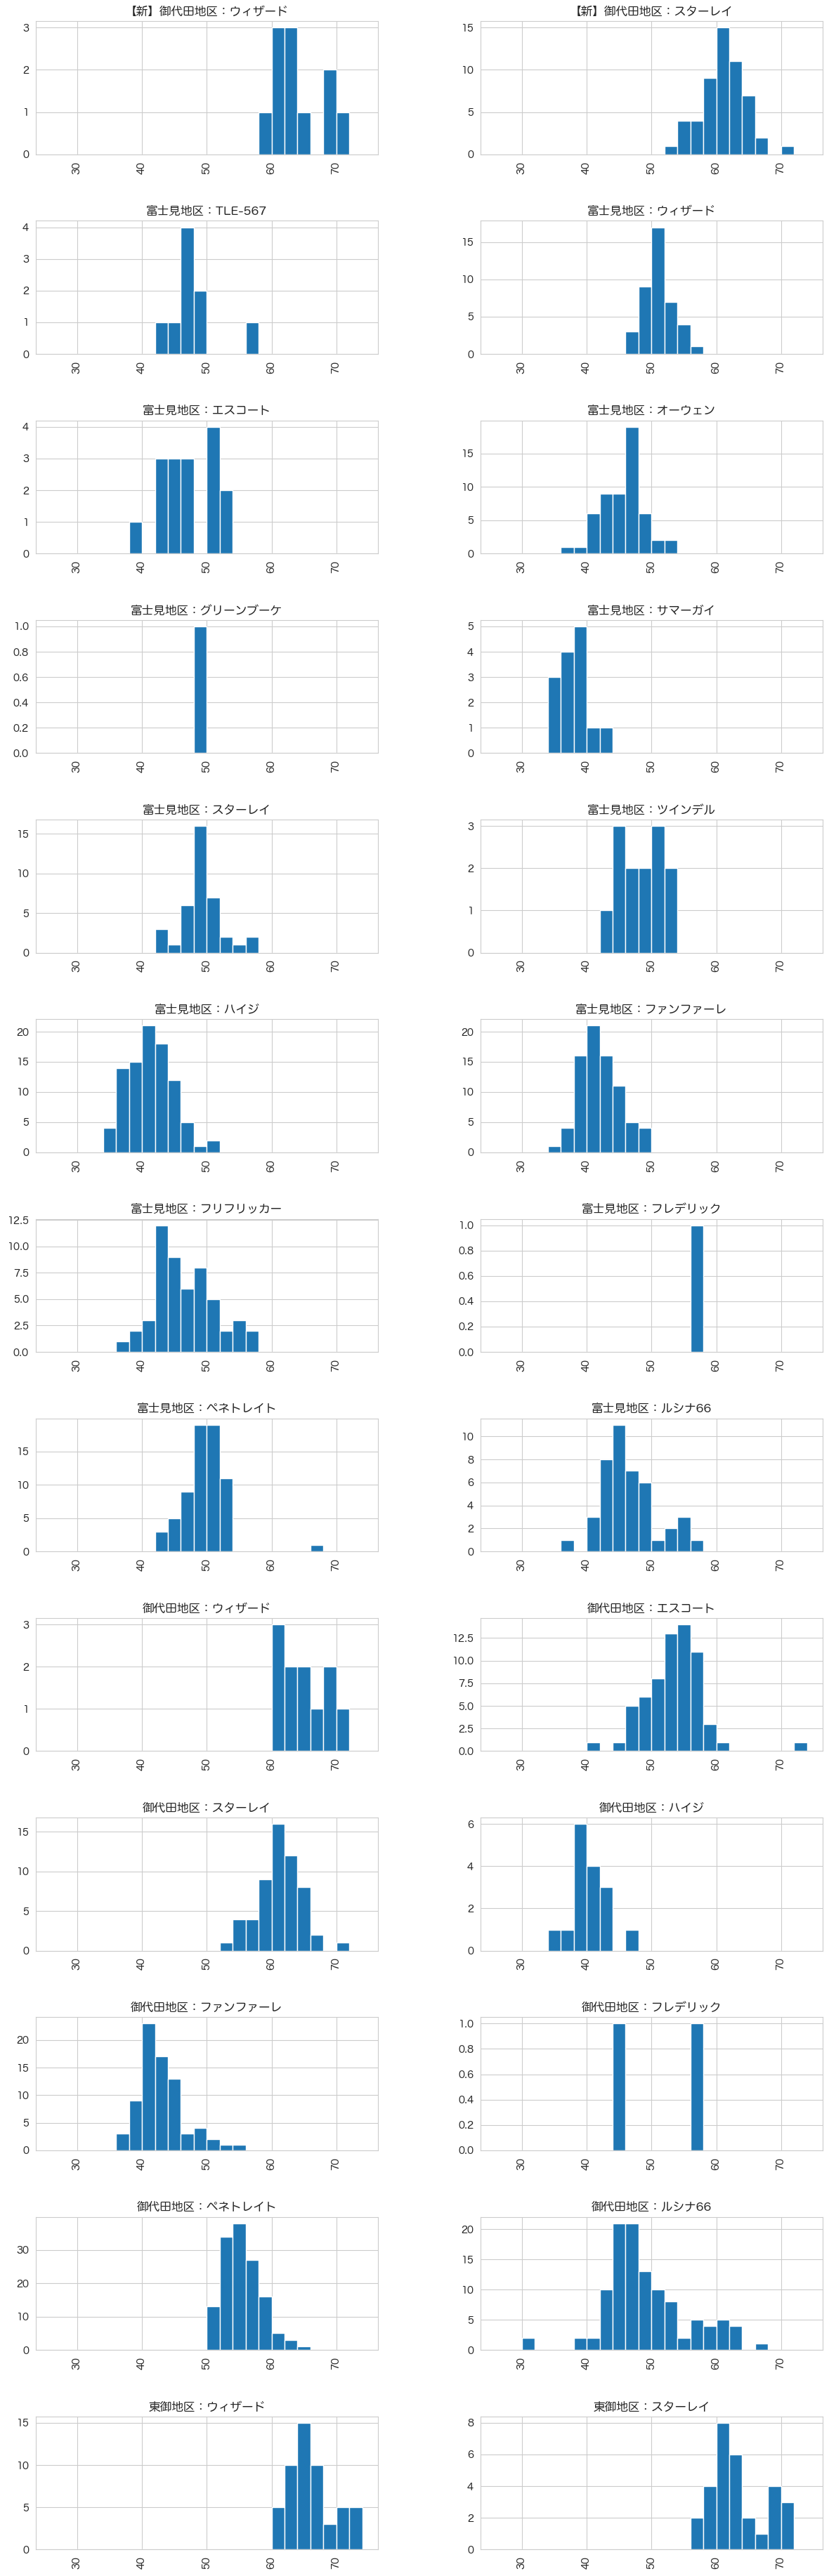

In [7]:
#--栽培グループ名ごとのヒストグラム作成
axes = df_days.hist('栽培日数', by='栽培グループ名', layout=(13,2), bins=np.arange(26,76,2), figsize=(14,48))
plt.show()

In [9]:
#--NDVIの統計量：栽培グループごとに計算
df_ndvi = df_farm.dropna().drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)
df_ndvi.groupby('栽培グループ名').aggregate({'NDVI値':['mean','std','min','max','count']}).round(2)

NDVI値                        
                mean   std   min   max count
栽培グループ名                                     
【新】御代田地区：ウィザード  0.66  0.09  0.53  0.81    11
【新】御代田地区：スターレイ  0.60  0.13  0.16  0.80    54
富士見地区：TLE-567   0.55  0.20  0.16  0.80     9
富士見地区：ウィザード     0.69  0.09  0.34  0.83    41
富士見地区：エスコート     0.62  0.08  0.50  0.77    16
富士見地区：オーウェン     0.60  0.17 -0.00  0.77    50
富士見地区：グリーンブーケ   0.60   NaN  0.60  0.60     1
富士見地区：サマーガイ     0.46  0.22  0.05  0.76    14
富士見地区：スターレイ     0.61  0.18  0.05  0.79    36
富士見地区：ツインデル     0.65  0.14  0.41  0.79    13
富士見地区：ハイジ       0.57  0.16  0.04  0.80    81
富士見地区：ファンファーレ   0.63  0.18 -0.02  0.83    78
富士見地区：フリフリッカー   0.68  0.10  0.39  0.84    53
富士見地区：フレデリック    0.81   NaN  0.81  0.81     1
富士見地区：ペネトレイト    0.67  0.10  0.30  0.80    67
富士見地区：ルシナ66     0.72  0.13  0.38  0.84    43
御代田地区：ウィザード     0.65  0.08  0.57  0.79    11
御代田地区：エスコート     0.68  0.10  0.41  0.86    59
御代田地区：スターレイ     0.61  0.13  0.16  0.80    57
御代田地区：ハイジ       0.49  0.21  0.06  0.79    15
御代田地区：ファンファーレ   0.67  0.16  0.02  0.83    75
御代田地区：フレデリック    0.41  0.18  0.28  0.54     2
御代田地区：ペネトレイト    0.62  0.14  0.04  0.82   137
御代田地区：ルシナ66     0.66  0.14  0.26  0.85   109
東御地区：ウィザード      0.63  0.13  0.34  0.85    53
東御地区：スターレイ      0.63  0.09  0.41  0.77    30

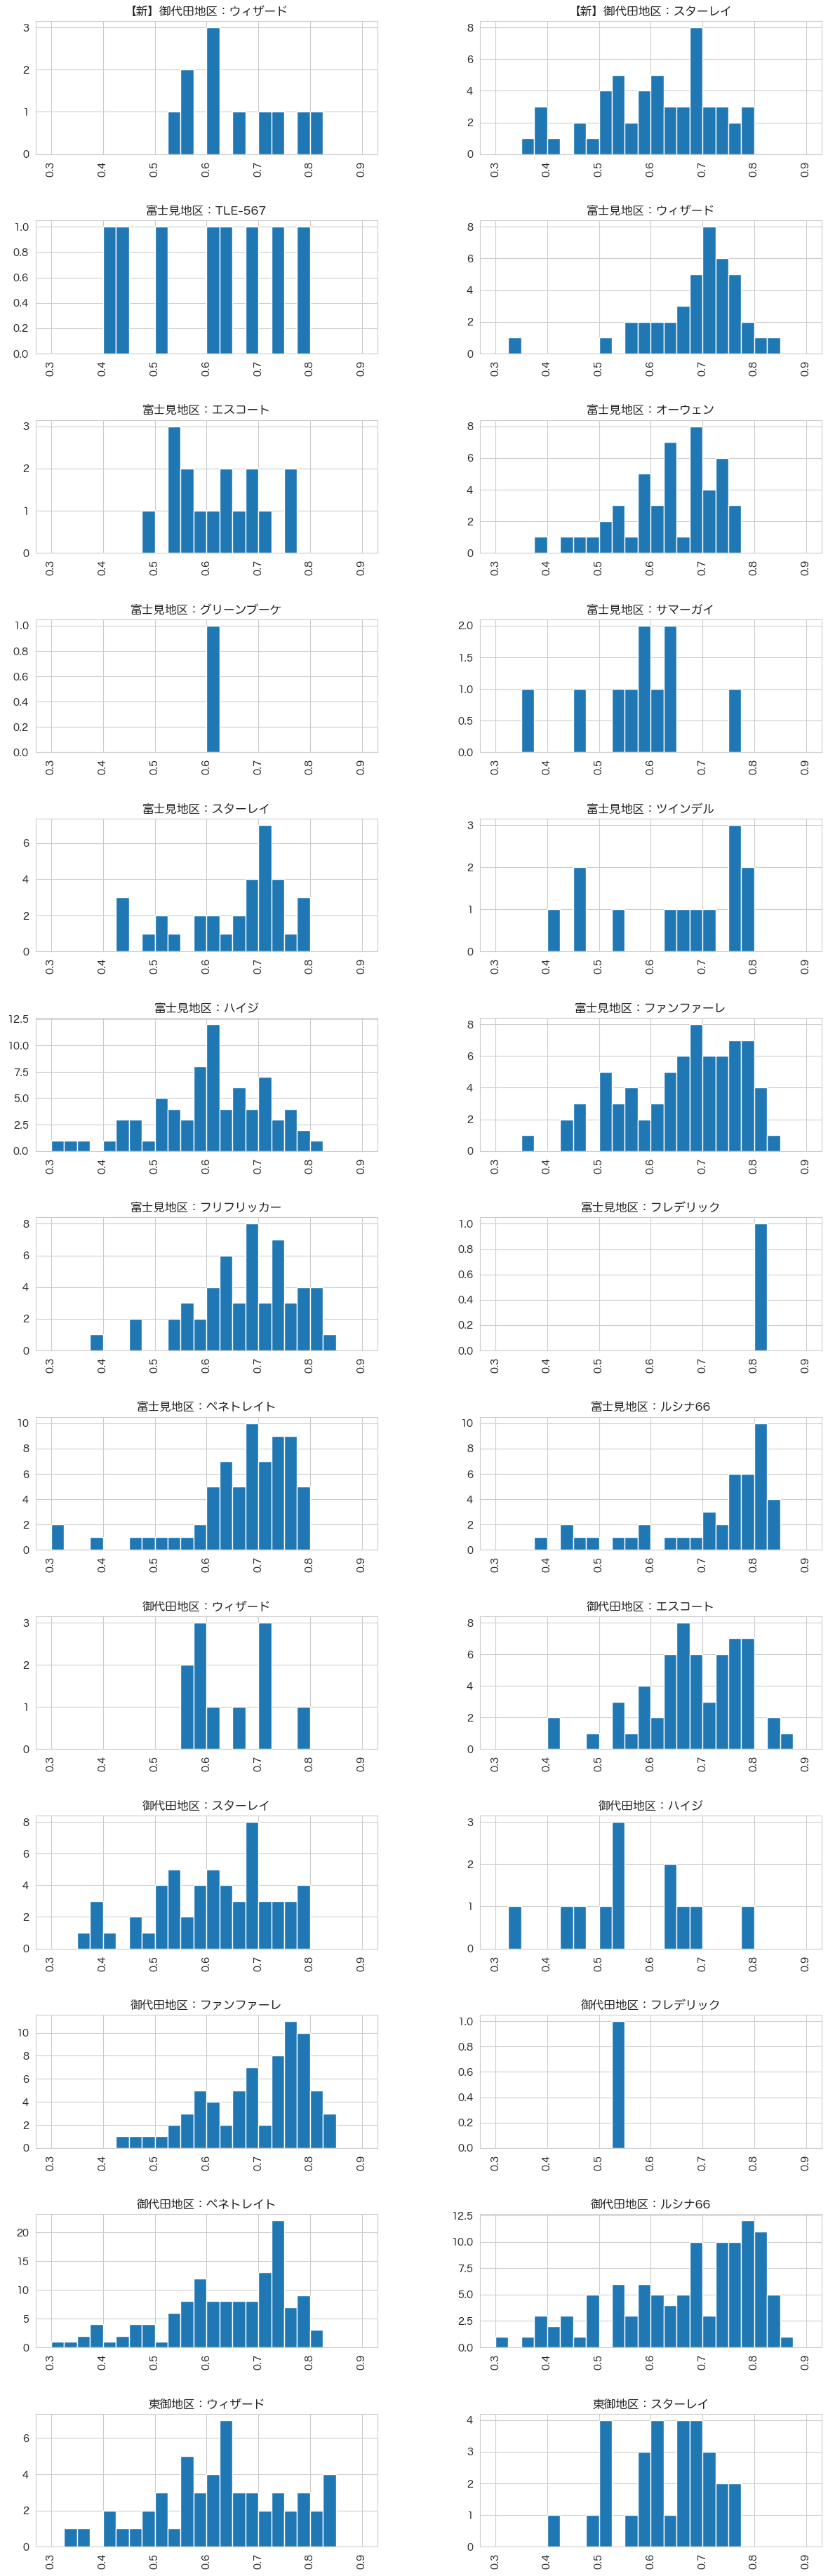

In [10]:
#--栽培グループ名ごとのヒストグラム作成
axes = df_ndvi.hist('NDVI値', by='栽培グループ名', layout=(13,2), bins=np.arange(0.3,0.9,0.025), figsize=(14,48))
plt.show()

- 品種ごとの収穫直前のNDVI平均値は地区による差が小さく見える
- ヒストグラムにすると、同一地区・同一品種でも、収穫直前のNDVIの分散が大きい
    - 収穫日を定植日からの日数で経験的に決めてないか
    - もしくは収穫作業のできる天気の条件があって収穫日が前後するのか
    - もしくはNDVIの解析誤差か

---

## 気象データを使った分析

### データ読み込み

In [6]:
#--変数設定
farm_list = "farm/topriver_farm.csv"

#--圃場IDリスト読み込み
df_IDs = pd.read_csv(farm_list)

#--圃場IDを栽培データに結合
df_farm = pd.merge(df_farm, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')

In [7]:
#--分析で使用する気象データ読み込み
df_weather = {}
df_climate = {}
for fid in df_farm['field_id'].unique():
    dfw = pd.read_csv(f"weather/topriver/weather_{fid}.csv", parse_dates=['date'])
    dfc = pd.read_csv(f"climate/topriver/climate_{fid}.csv", parse_dates=['date'])
    df_weather[fid] = dfw
    df_climate[fid] = dfc

### 栽培日数と気象データの分析

In [47]:
#--ユニークな圃場・栽培日数のデータセット作成
df_grow = df_farm.drop_duplicates(subset=['栽培グループ名','圃場名','年度'], keep='last').reset_index(drop=True)

#--栽培期間における気象データの合計値を計算
# Tbase = 4
wx_sum_list = []
wx_cols = None
for index, row in df_grow.iterrows():
    fid = row['field_id']
    s_date = row['定植日']
    e_date = row['収穫日']
    # print(fid, s_date, e_date)
    df = df_weather[fid].query("date >= @s_date and date <= @e_date").reset_index(drop=True)
    df['TMP_GDD2'] = (df['TMP_mea'] - 2).clip(lower=0).round(2)
    df['TMP_GDD4'] = (df['TMP_mea'] - 4).clip(lower=0).round(2)
    df['TMX_GDD6'] = (df['TMP_max'] - 6).clip(lower=0).round(2)
    df['TMX_GDD10'] = (df['TMP_max'] - 10).clip(lower=0).round(2)
    sr = df.set_index('date').sum(axis=0).round(2)
    if wx_cols is None:
        wx_cols = sr.index.tolist()
    wx_sum_list.append(sr.tolist())

df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

#--圃場・栽培日数データに気象データを結合
df_grow = pd.concat([df_grow, df_wx_sum], axis=1)

#### 気温の積算値

In [58]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "TMP_GDD2"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
【新】御代田地区：ウィザード,394.94,46.65,330.7,498.0,11,0.12
【新】御代田地区：スターレイ,468.57,68.72,348.0,650.2,54,0.15
富士見地区：TLE-567,663.02,85.88,558.2,773.6,9,0.13
富士見地区：ウィザード,491.80,56.32,385.0,567.2,41,0.11
富士見地区：エスコート,690.50,79.46,465.7,804.4,16,0.12
富士見地区：オーウェン,689.46,51.41,596.8,802.7,55,0.07
富士見地区：グリーンブーケ,600.20,NaN,600.2,600.2,1,NaN
富士見地区：サマーガイ,804.00,42.77,726.9,893.0,14,0.05
富士見地区：スターレイ,557.84,64.88,395.8,699.1,38,0.12


In [ ]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['TMP_mea', 'TMP_max', 'TMP_min', 'TMP_GDD2', 'TMP_GDD4', 'TMX_GDD6', 'TMX_GDD10']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

/var/folders/0r/r4nn26p96717l30kctj4_zjr0000gn/T/ipykernel_1824/329770305.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df_CV['best'] = df_CV.idxmin(axis=1)


best
TMP_max      17
TMP_mea       4
TMX_GDD6      1
TMP_min       1
TMX_GDD10     1
Name: count, dtype: int64

,TMP_mea,TMP_max,TMP_min,TMP_GDD2,TMP_GDD4,TMX_GDD6,TMX_GDD10,best
栽培グループ名,,,,,,,,
【新】御代田地区：ウィザード,0.09,0.04,0.70,0.12,0.15,0.08,0.12,TMP_max
【新】御代田地区：スターレイ,0.12,0.06,0.45,0.15,0.19,0.10,0.15,TMP_max
富士見地区：TLE-567,0.12,0.09,0.19,0.13,0.15,0.11,0.13,TMP_max
富士見地区：ウィザード,0.10,0.06,0.22,0.11,0.14,0.09,0.12,TMP_max
富士見地区：エスコート,0.11,0.10,0.15,0.12,0.12,0.11,0.12,TMP_max
富士見地区：オーウェン,0.07,0.06,0.13,0.07,0.08,0.06,0.06,TMX_GDD6
富士見地区：グリーンブーケ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
富士見地区：サマーガイ,0.05,0.05,0.07,0.05,0.05,0.05,0.05,TMP_max
富士見地区：スターレイ,0.10,0.07,0.19,0.12,0.14,0.09,0.11,TMP_max


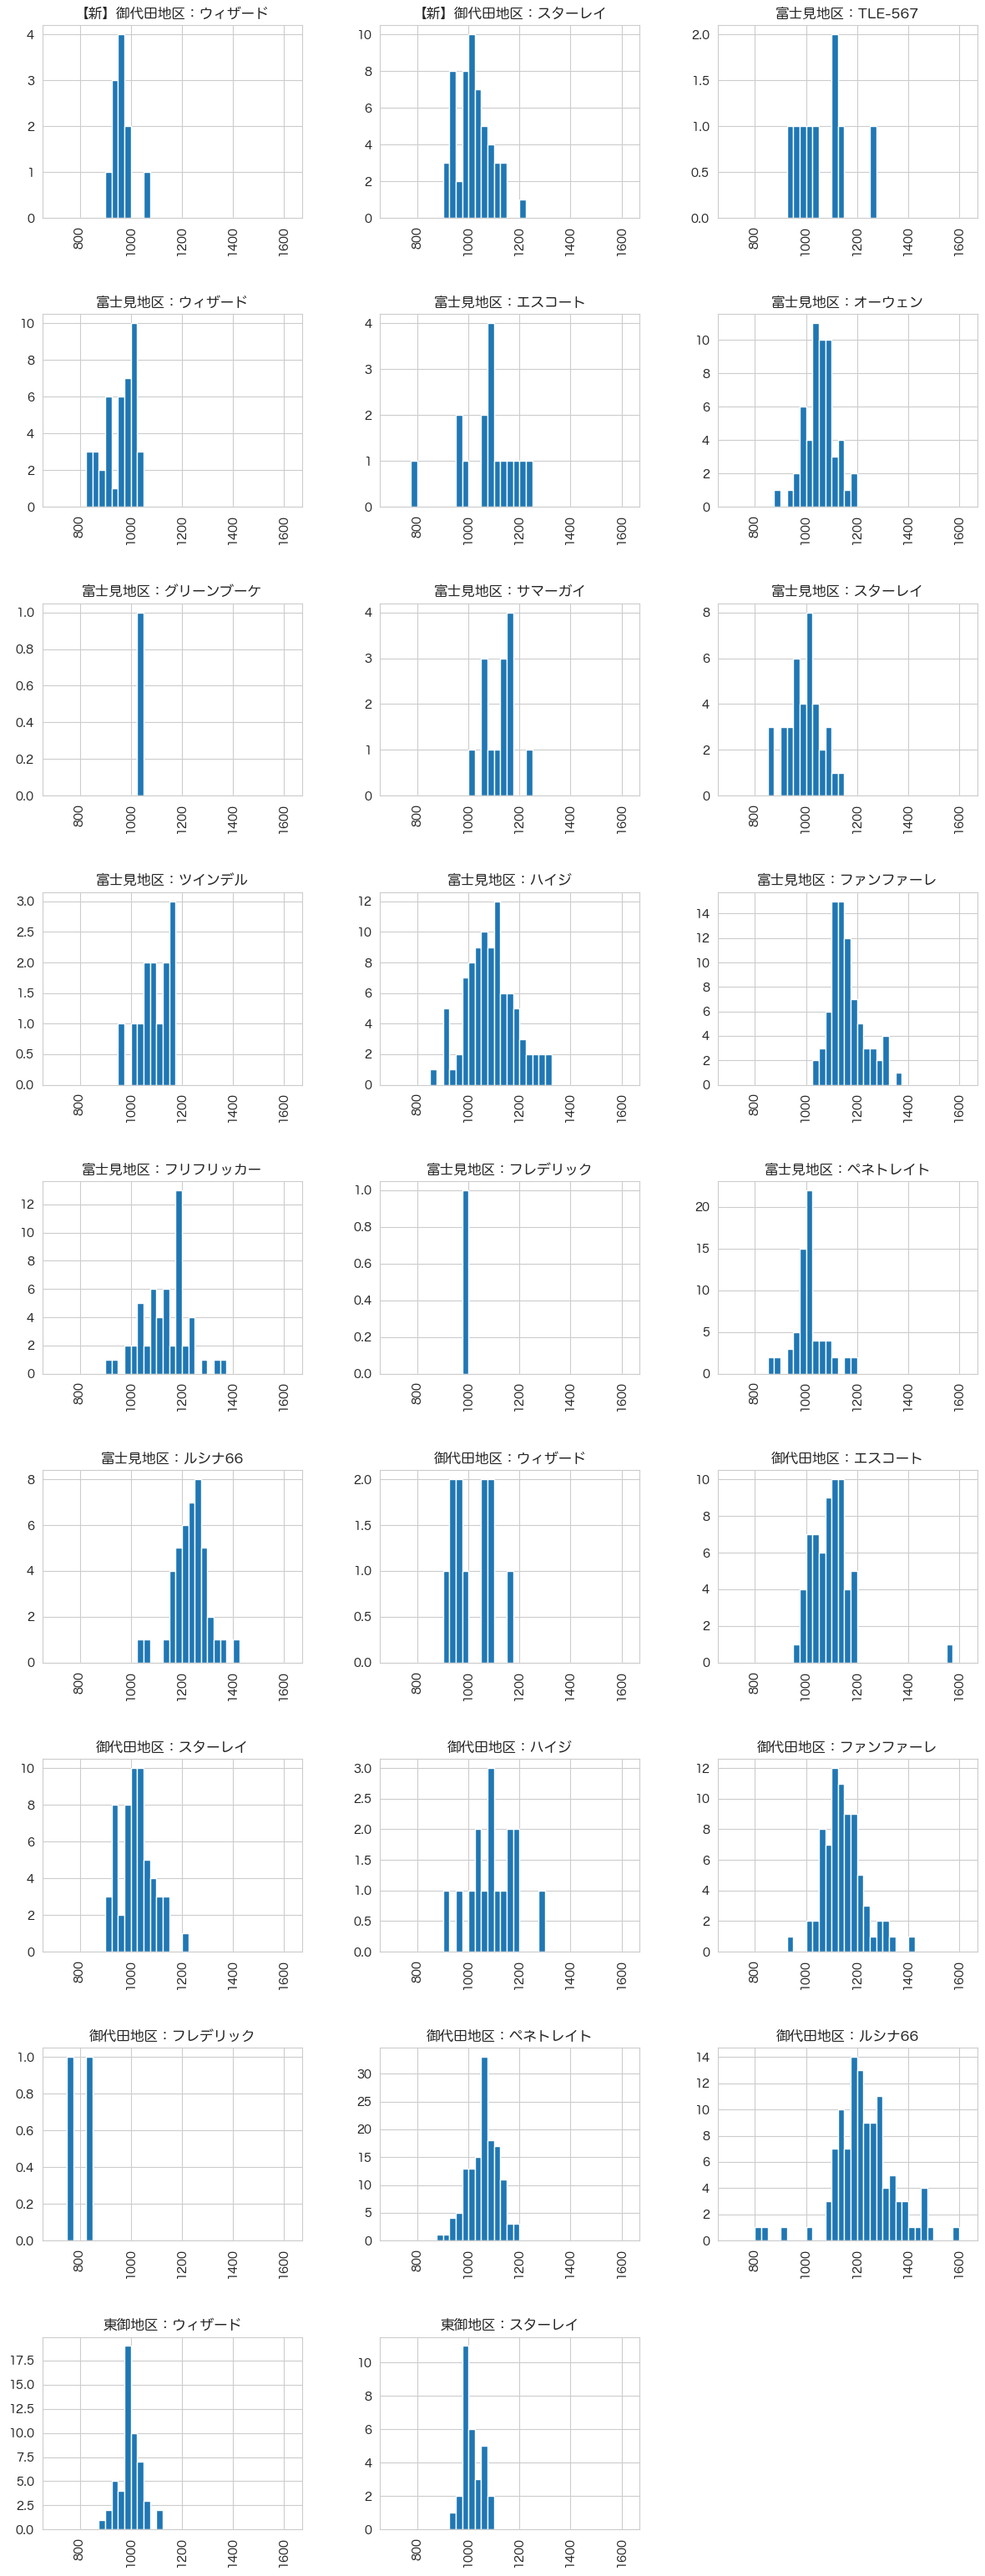

In [56]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "TMP_max"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(9,3), bins=np.arange(x_min, x_max, 25), figsize=(14,40))
plt.show()

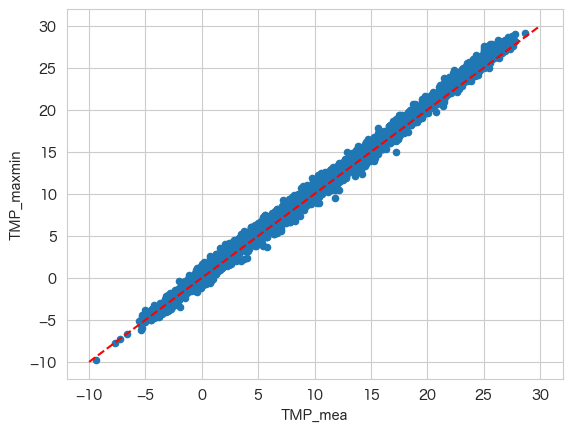

In [11]:
#--TMP_meaより、TMP_maxとTMP_minの平均の方がいいか？
# → ほぼ同じなので、どちらでもよい
df = df_weather['topriver001'].copy()
df['TMP_maxmin'] = (df['TMP_max'] + df['TMP_min']) / 2
df.set_index('date', inplace=True)
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
df.plot.scatter(x='TMP_mea', y='TMP_maxmin', ax=ax)
ax.plot([-10,30], [-10,30], color='red', linestyle='--')
plt.show()

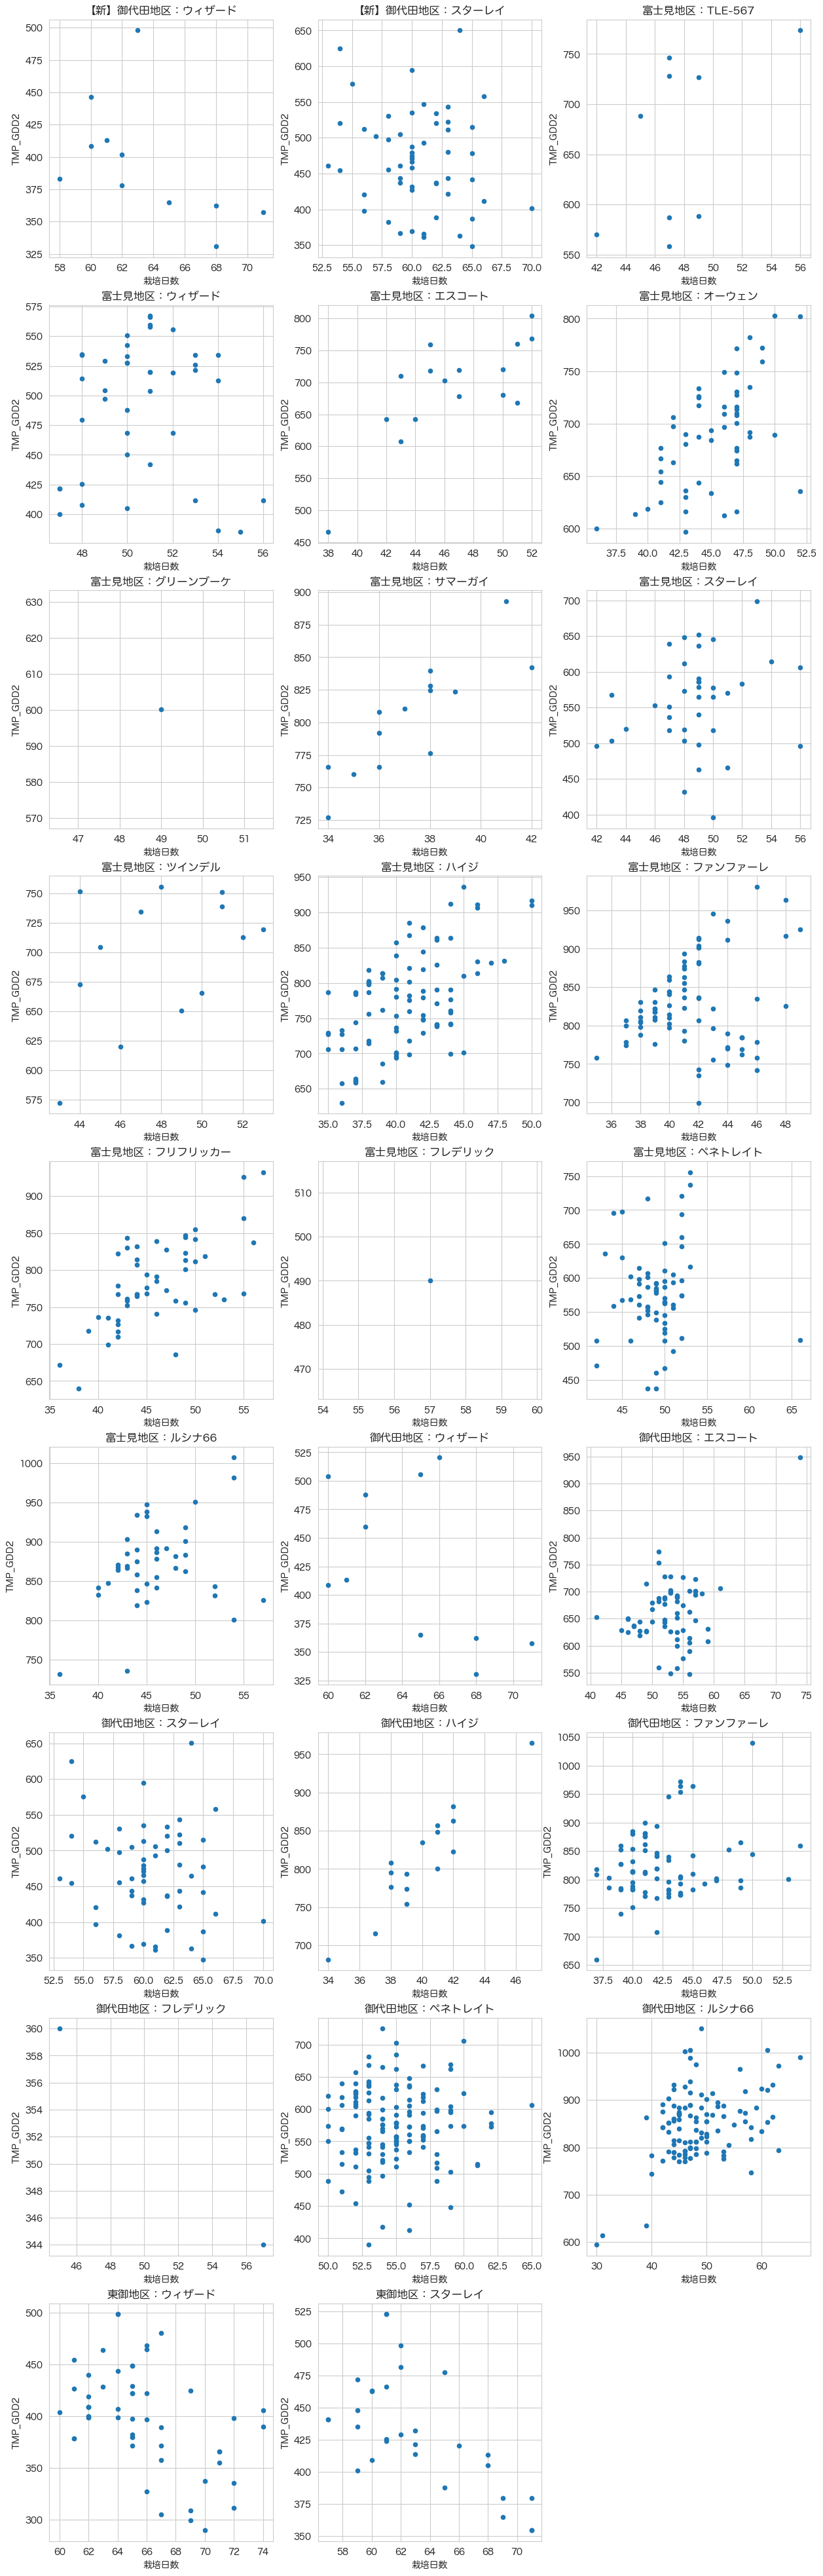

In [75]:
#--栽培グループごとに栽培日数と積算気温の散布図を作成
# 積算気温が支配的なら、栽培日数にかかわららず横一直線に近くなるはず
elm = "TMP_GDD2"
fig = plt.figure(figsize=(15,50))
for i, (grp, df) in enumerate(df_grow.groupby('栽培グループ名')):
    ax = fig.add_subplot(9,3,i+1)
    df.plot.scatter(x='栽培日数', y=elm, title=grp, ax=ax)
plt.show()

#### 日射量や日照時間の積算値

In [64]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "DLR"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
【新】御代田地区：ウィザード,1635.14,91.61,1486.44,1808.88,11,0.06
【新】御代田地区：スターレイ,1595.84,89.36,1436.17,1796.96,54,0.06
富士見地区：TLE-567,1477.74,121.90,1294.11,1725.92,9,0.08
富士見地区：ウィザード,1406.18,65.60,1278.98,1516.91,41,0.05
富士見地区：エスコート,1462.38,133.92,1109.52,1643.80,16,0.09
富士見地区：オーウェン,1436.54,101.65,1172.50,1663.46,55,0.07
富士見地区：グリーンブーケ,1460.33,NaN,1460.33,1460.33,1,NaN
富士見地区：サマーガイ,1318.66,83.32,1188.46,1481.30,14,0.06
富士見地区：スターレイ,1409.96,88.93,1213.19,1600.12,38,0.06


In [65]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['SSD', 'GSR', 'DLR']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

/var/folders/0r/r4nn26p96717l30kctj4_zjr0000gn/T/ipykernel_1824/672095058.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df_CV['best'] = df_CV.idxmin(axis=1)


best
DLR    22
GSR     1
SSD     1
Name: count, dtype: int64

,SSD,GSR,DLR,best
栽培グループ名,,,,
【新】御代田地区：ウィザード,0.07,0.06,0.06,DLR
【新】御代田地区：スターレイ,0.08,0.06,0.06,DLR
富士見地区：TLE-567,0.10,0.09,0.08,DLR
富士見地区：ウィザード,0.08,0.06,0.05,DLR
富士見地区：エスコート,0.10,0.09,0.09,GSR
富士見地区：オーウェン,0.19,0.10,0.07,DLR
富士見地区：グリーンブーケ,NaN,NaN,NaN,NaN
富士見地区：サマーガイ,0.11,0.06,0.06,DLR
富士見地区：スターレイ,0.08,0.06,0.06,DLR


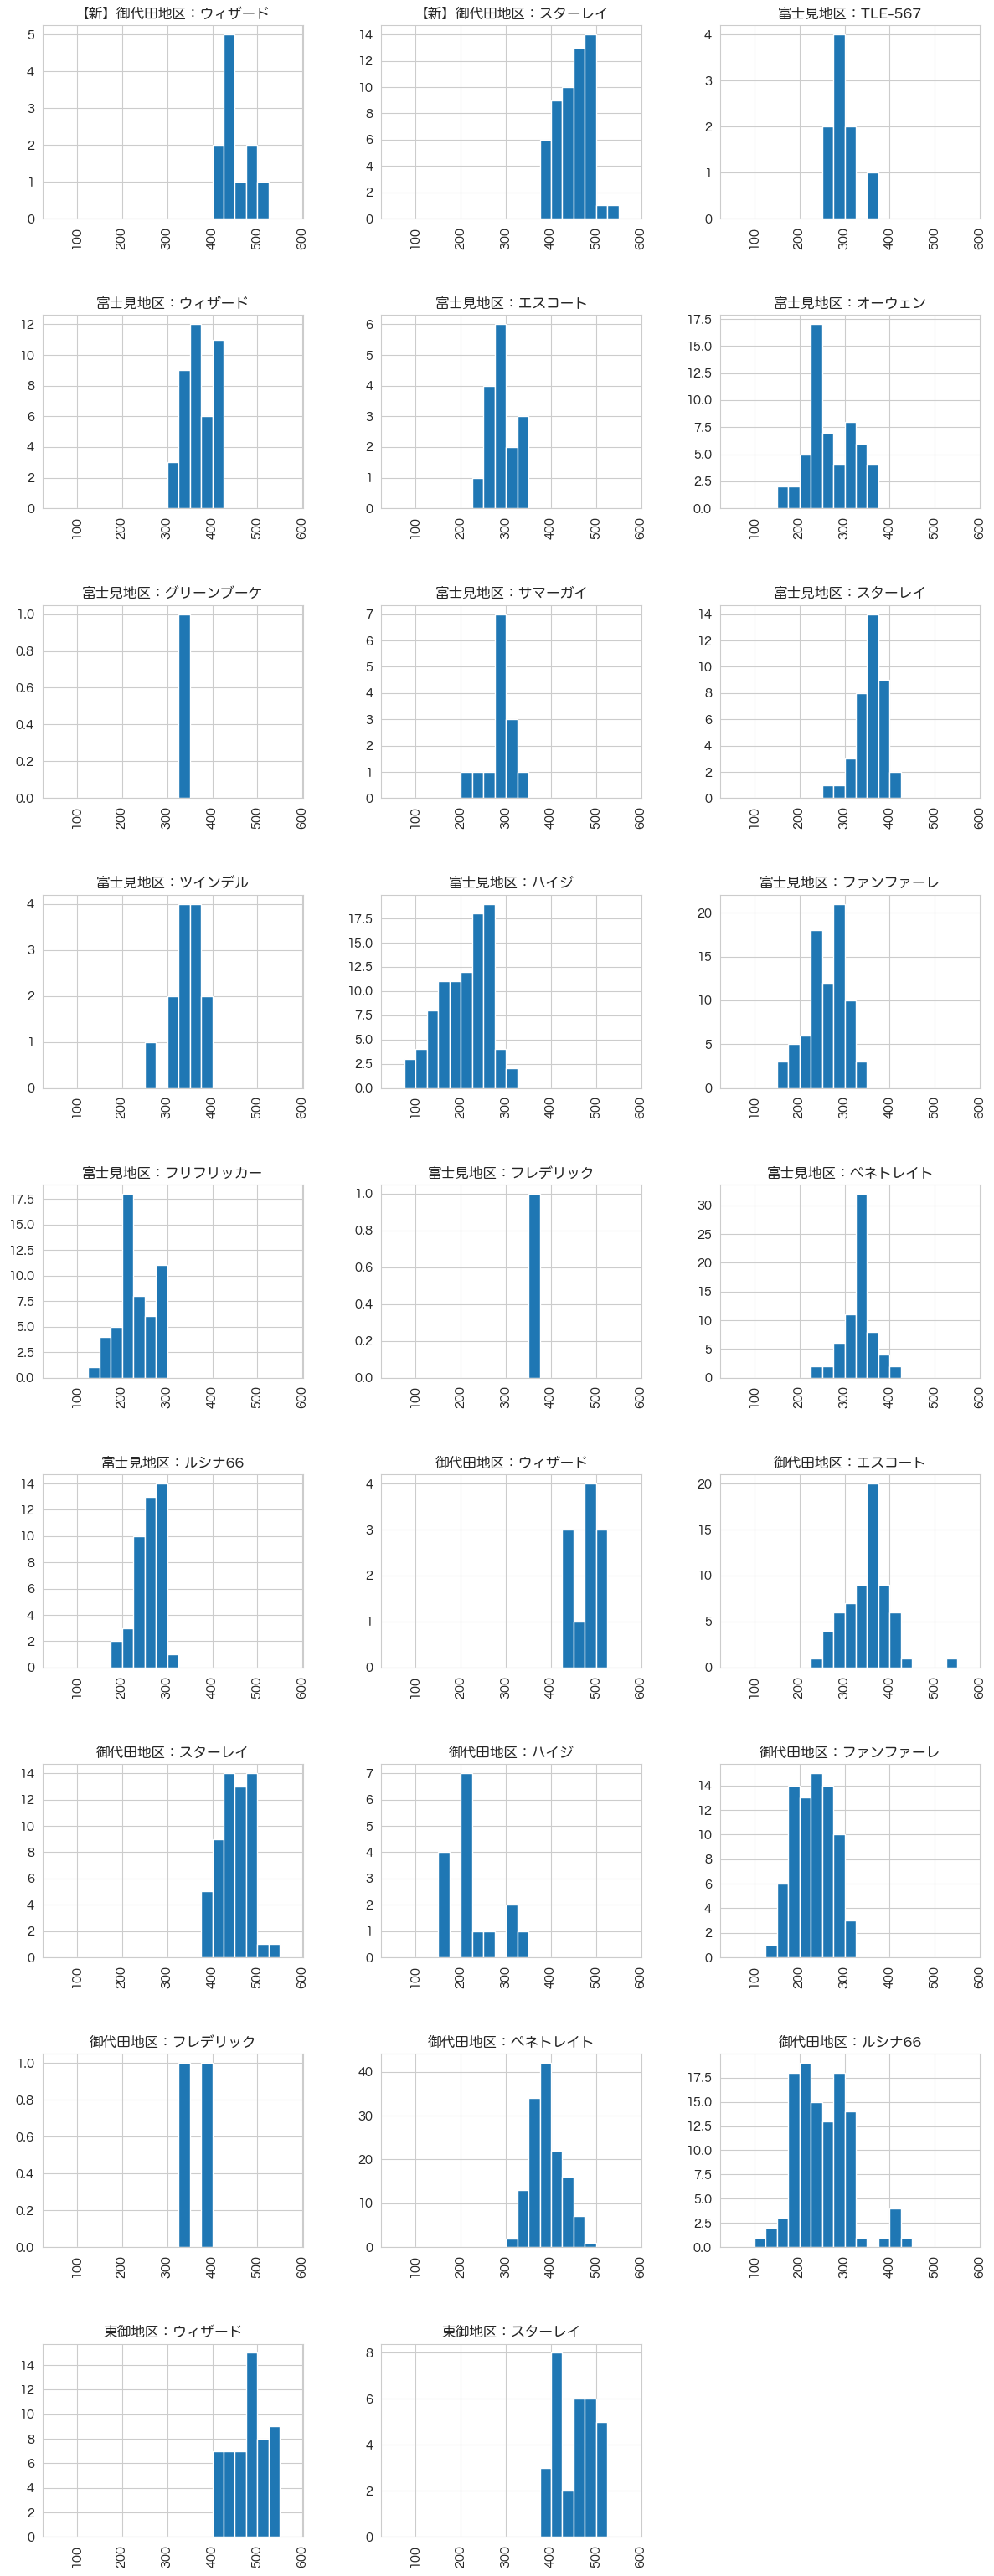

In [73]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "SSD"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(9,3), bins=np.arange(x_min, x_max, 25), figsize=(14,40))
plt.show()

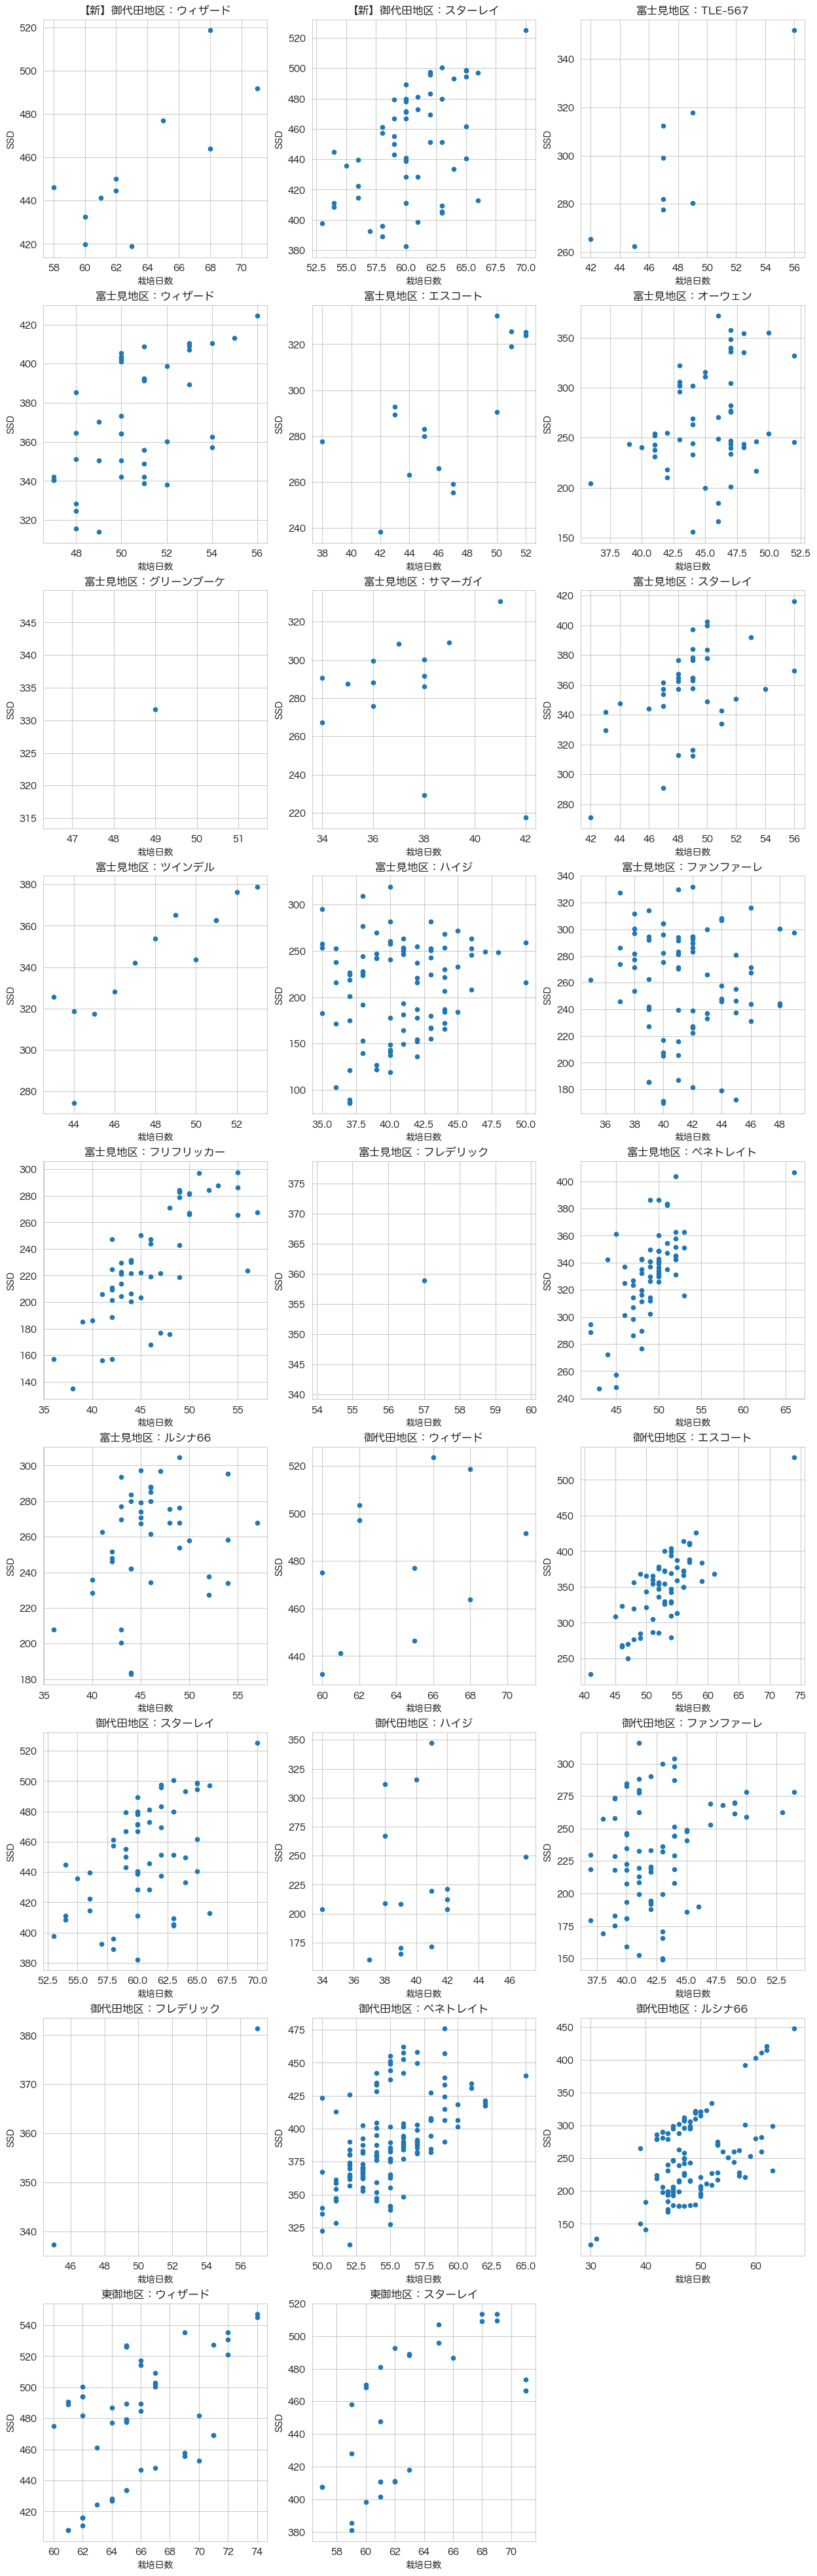

In [ ]:
#--栽培グループごとに放射量関係の気象要素の散布図を作成
# 積算気温が支配的なら、栽培日数にかかわららず横一直線に近くなるはず
elm = "SSD"
fig = plt.figure(figsize=(15,50))
for i, (grp, df) in enumerate(df_grow.groupby('栽培グループ名')):
    ax = fig.add_subplot(9,3,i+1)
    df.plot.scatter(x='栽培日数', y=elm, title=grp, ax=ax)
plt.show()

#### 降水量積算値や平均湿度

In [84]:
#--湿度の平均値を計算しておく
df_grow['RH_mea'] = (df_grow['RH'] / df_grow['栽培日数']).round(2)

In [87]:
#--栽培グループごとの積算気温のばらつきを見る
elm = "RH"
df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
df_agg.columns = ['mean','std','min','max','count']
df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
df_agg.round(2)

,mean,std,min,max,count,CV
栽培グループ名,,,,,,
【新】御代田地区：ウィザード,4861.50,279.29,4251.5,5289.2,11,0.06
【新】御代田地区：スターレイ,4596.33,363.15,3908.9,5444.2,54,0.08
富士見地区：TLE-567,3591.66,285.64,3194.9,4211.9,9,0.08
富士見地区：ウィザード,3416.52,195.35,3162.3,3874.8,41,0.06
富士見地区：エスコート,3470.59,320.56,2667.0,3975.0,16,0.09
富士見地区：オーウェン,3413.19,309.75,2732.7,4052.3,55,0.09
富士見地区：グリーンブーケ,3656.40,NaN,3656.4,3656.4,1,NaN
富士見地区：サマーガイ,2885.79,267.53,2568.5,3552.5,14,0.09
富士見地区：スターレイ,3345.87,260.18,2808.7,4002.7,38,0.08


In [83]:
#--どの積算気温の取り方が最もばらつきが小さいか、変動係数で見る
df_CV = pd.DataFrame()
for elm in ['APCP', 'APCPRA']:
    df_agg = df_grow.groupby('栽培グループ名').aggregate({elm:['mean','std','min','max','count']})
    df_agg.columns = ['mean','std','min','max','count']
    df_agg['CV'] = (df_agg['std'] / df_agg['mean'])
    df_CV[elm] = df_agg.get('CV')
# df_CV.round(2)

df_CV['best'] = df_CV.idxmin(axis=1)
# cols = df_CV.select_dtypes(include=[np.number]).columns
# df_CV['best'] = df_CV[cols].idxmin(axis=1)
display(df_CV['best'].value_counts())
display(df_CV.round(2))

# → TMP_maxが最もばらつきが少ない

/var/folders/0r/r4nn26p96717l30kctj4_zjr0000gn/T/ipykernel_1824/3028311973.py:10: FutureWarning: The behavior of DataFrame.idxmin with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df_CV['best'] = df_CV.idxmin(axis=1)


best
APCPRA    21
APCP       3
Name: count, dtype: int64

,APCP,APCPRA,best
栽培グループ名,,,
【新】御代田地区：ウィザード,0.17,0.10,APCPRA
【新】御代田地区：スターレイ,0.26,0.18,APCPRA
富士見地区：TLE-567,0.26,0.27,APCP
富士見地区：ウィザード,0.26,0.22,APCPRA
富士見地区：エスコート,0.26,0.24,APCPRA
富士見地区：オーウェン,0.29,0.26,APCPRA
富士見地区：グリーンブーケ,NaN,NaN,NaN
富士見地区：サマーガイ,0.45,0.23,APCPRA
富士見地区：スターレイ,0.34,0.28,APCPRA


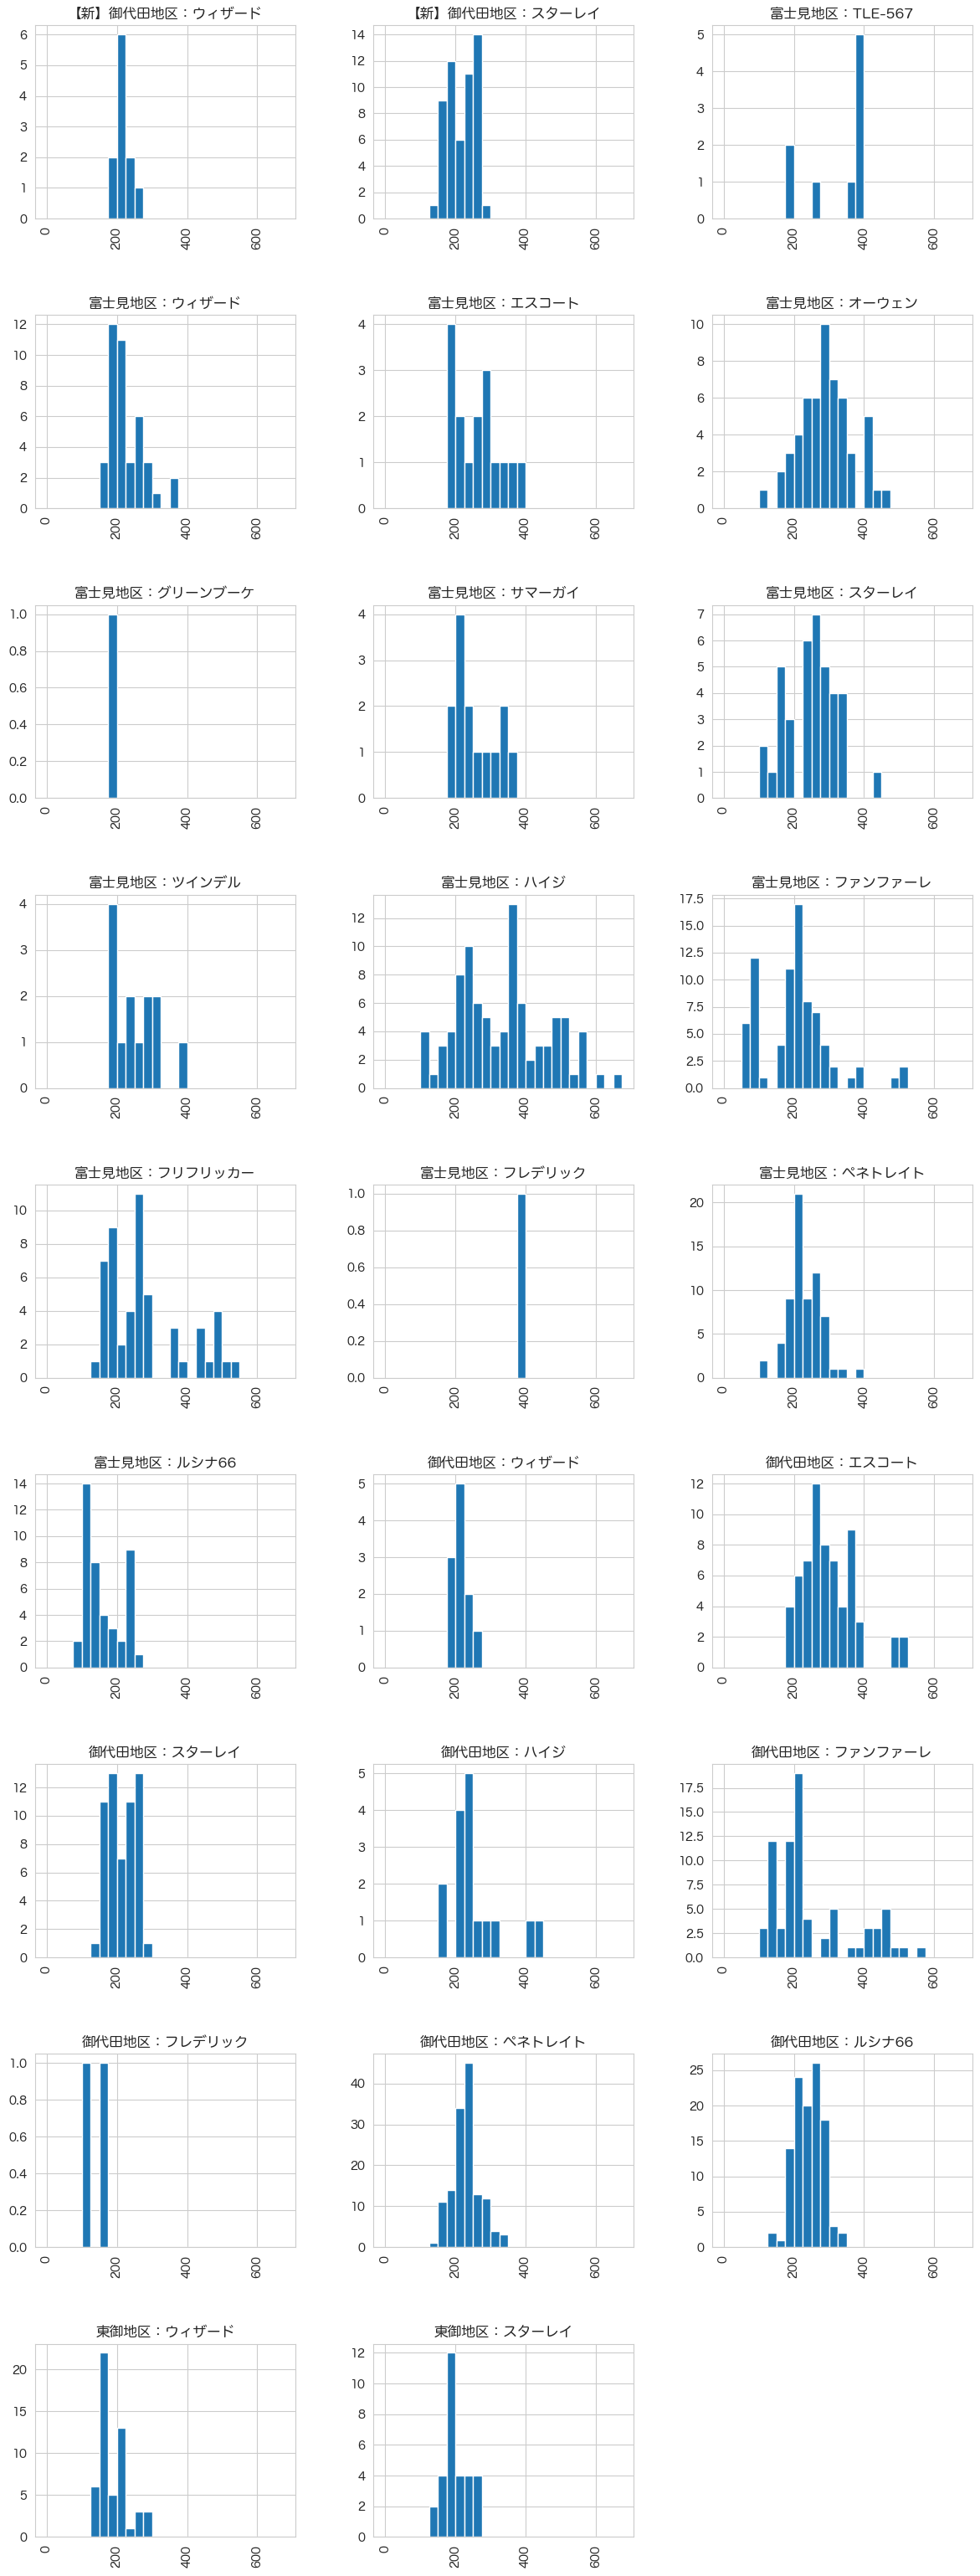

In [91]:
#--栽培グループ名ごとのばらつきをヒストグラムで見る
elm = "APCPRA"
x_max = round((df_grow[elm].max() + 50)/50) * 50
x_min = round((df_grow[elm].min() - 50)/50) * 50
axes = df_grow.hist(elm, by='栽培グループ名', layout=(9,3), bins=np.arange(x_min, x_max, 25), figsize=(14,40))
plt.show()

## NDVI値を曲線フィッティング

In [6]:
#--シグモイド関数を定義
def logistic4(x, a, K, b, x0):
    return a + (K - a) / (1.0 + np.exp(-b * (x - x0)))

In [7]:
#--画像出力先フォルダ作成
fig_dir = "fig/topriver/sigmoid"
os.makedirs(fig_dir, exist_ok=True)

In [ ]:
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
#--シグモイド関数でフィッティングした曲線と±2σの帯を表示
for group, df_group in df_farm.groupby('栽培グループ名'):
    #--シグモイド曲線でフィッティング
    x = df_group.dropna()['経過日'].values
    y = df_group.dropna()['NDVI値'].values

    a0  = y.min()  # 初期NDVI
    K0  = y.max()  # 最大NDVI
    x0_ = x.mean() # 立ち上がり中心
    b0  = 0.1      # 傾き（0.1〜0.2くらいから試す）
    p0 = [a0, K0, b0, x0_] # 初期パラメータ

    params, cov = curve_fit(logistic4, x, y, p0=p0, maxfev=10000)

    #--シグモイド曲線描画のための変数
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = logistic4(x_fit, *params)

    #--残差と標準偏差を計算し、±2σの帯を計算
    y_pred = logistic4(x, *params)
    residuals = y - y_pred
    sigma = np.std(residuals)
    upper = y_fit + 2*sigma
    lower = y_fit - 2*sigma

    #--グラフ描画（凡例は表示しない）
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', ax=ax)
    sns.lineplot(x=x_fit, y=y_fit, c='black', linestyle='--', ax=ax)
    ax.fill_between(x_fit, lower, upper, alpha=0.3)
    ax.set_title(group)
    #--画像保存 or 画像表示
    plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    plt.close()
    # plt.show()

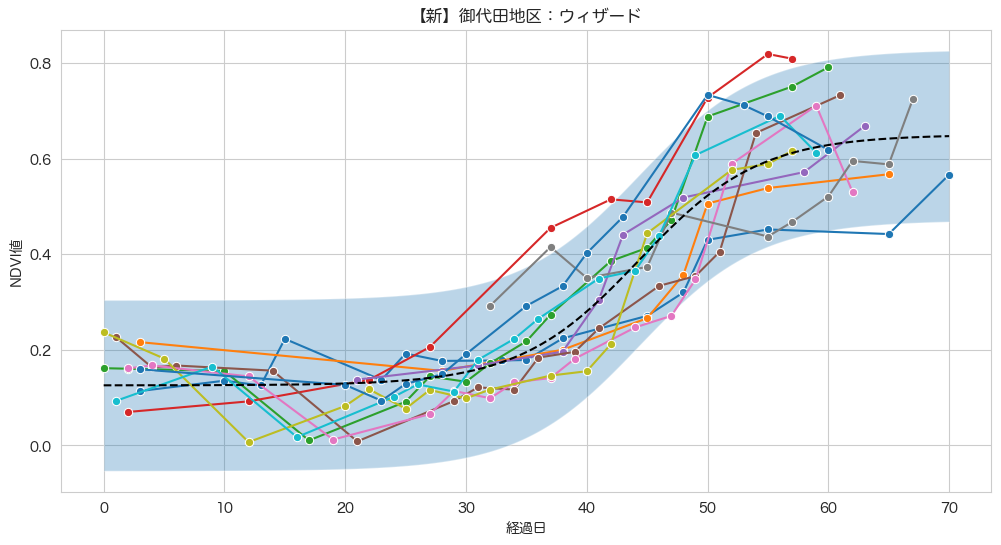

In [9]:
#--Notebook上での確認用
#--栽培グループ（地区と品種）ごとに、年度・圃場ごとの折れ線グラフを描画
#--シグモイド関数でフィッティングした曲線と±2σの帯を表示
for group, df_group in df_farm.groupby('栽培グループ名'):
    #--シグモイド曲線でフィッティング
    x = df_group.dropna()['経過日'].values
    y = df_group.dropna()['NDVI値'].values

    a0  = y.min()  # 初期NDVI
    K0  = y.max()  # 最大NDVI
    x0_ = x.mean() # 立ち上がり中心
    b0  = 0.1      # 傾き（0.1〜0.2くらいから試す）
    p0 = [a0, K0, b0, x0_] # 初期パラメータ

    params, cov = curve_fit(logistic4, x, y, p0=p0, maxfev=10000)
    # a_fit, K_fit, b_fit, x0_fit = params

    #--シグモイド曲線描画のための変数
    x_fit = np.linspace(x.min(), x.max(), 300)
    y_fit = logistic4(x_fit, *params)

    #--残差と標準偏差を計算し、±2σの帯を計算
    y_pred = logistic4(x, *params)
    residuals = y - y_pred
    sigma = np.std(residuals)
    upper = y_fit + 2*sigma
    lower = y_fit - 2*sigma

    #--グラフ描画（凡例は表示しない）
    fig = plt.figure(figsize=(12,6))
    ax = fig.add_subplot(1,1,1)
    for (field, year), df in df_group.groupby(['圃場名','年度']):
        # sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', label=f'{field}:{year}', ax=ax)
        sns.lineplot(data=df, x='経過日', y='NDVI値', marker='o', ax=ax)
    # sns.lineplot(x=x_fit, y=y_fit, c='black', label='fitted curve', linestyle='--', ax=ax)
    sns.lineplot(x=x_fit, y=y_fit, c='black', linestyle='--', ax=ax)
    # ax.fill_between(x_fit, lower, upper, alpha=0.3, label='±2σ band')
    ax.fill_between(x_fit, lower, upper, alpha=0.3)
    # ax.legend()
    ax.set_title(group)
    #--画像保存 or 画像表示
    # plt.savefig(f"{fig_dir}/{group}.png", bbox_inches='tight')
    # plt.close()
    plt.show()
    break

# END